In [1]:
pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\dileep anna\anaconda3\lib\site-packages (2.2.2)




[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("candidate_responses.csv")

df['answer_text'] = df['answer_text'].str.strip()
df = df.drop_duplicates()

df


,candidate_id,answer_text,submission_time
0,101,I am a hardworking and dedicated engineer with...,2026-02-10
1,102,I good at coding and team work,2026-02-10
2,103,"I have experience in Python, SQL and data anal...",2026-02-11
3,104,I am passionate about learning and solving pro...,2026-02-11
4,105,My strength is communication and structured th...,2026-02-11


In [4]:
def length_score(text):
    word_count = len(text.split())
    if word_count > 12:
        return 5
    elif word_count > 8:
        return 4
    elif word_count > 5:
        return 3
    else:
        return 2

def grammar_score(text):
    if text.startswith("I"):
        return 4
    else:
        return 3

keywords = ["engineer", "python", "sql", "analysis", "learning"]

def relevance_score(text):
    score = 0
    for word in keywords:
        if word.lower() in text.lower():
            score += 1
    return min(score, 5)


In [5]:
df['length_score'] = df['answer_text'].apply(length_score)
df['grammar_score'] = df['answer_text'].apply(grammar_score)
df['relevance_score'] = df['answer_text'].apply(relevance_score)

df['final_score'] = df[['length_score','grammar_score','relevance_score']].mean(axis=1)

df


,candidate_id,answer_text,submission_time,length_score,grammar_score,relevance_score,final_score
0,101,I am a hardworking and dedicated engineer with...,2026-02-10,4,4,1,3.000000
1,102,I good at coding and team work,2026-02-10,3,4,0,2.333333
2,103,"I have experience in Python, SQL and data anal...",2026-02-11,4,4,3,3.666667
3,104,I am passionate about learning and solving pro...,2026-02-11,3,4,1,2.666667
4,105,My strength is communication and structured th...,2026-02-11,3,3,0,2.000000


In [6]:
mean_score = df['final_score'].mean()
std_dev = df['final_score'].std()
variance = df['final_score'].var()

print("Mean Score:", mean_score)
print("Standard Deviation:", std_dev)
print("Variance:", variance)


Mean Score: 2.7333333333333334
Standard Deviation: 0.6411794687223781
Variance: 0.41111111111111104


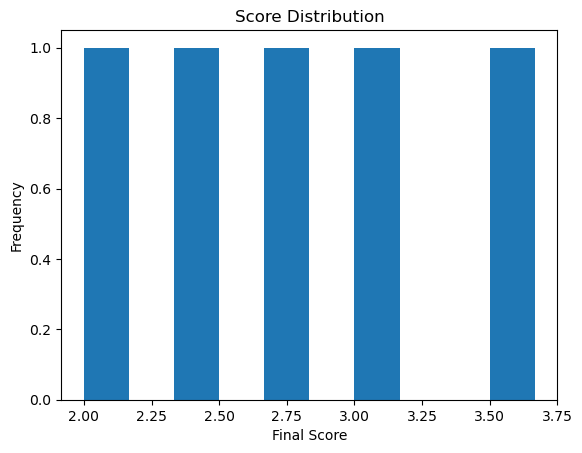

In [7]:
import matplotlib.pyplot as plt

plt.hist(df['final_score'])
plt.title("Score Distribution")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()


In [9]:
df.to_csv("graded_responses.csv", index=False)


In [10]:
import sqlite3

In [11]:
conn = sqlite3.connect("shl_database.db")
df.to_sql("graded_responses", conn, if_exists="replace", index=False)

5

In [17]:
#Average Score
query1 = """
SELECT AVG(final_score) AS average_score
FROM graded_responses;
"""

pd.read_sql_query(query1, conn)

,average_score
0,2.733333


In [13]:
#Top Performer
query2 = """
SELECT candidate_id, final_score
FROM graded_responses
ORDER BY final_score DESC
LIMIT 1;
"""

pd.read_sql_query(query2, conn)


,candidate_id,final_score
0,103,3.666667


In [14]:
#Score Distribution
query3 = """
SELECT final_score, COUNT(*) AS frequency
FROM graded_responses
GROUP BY final_score;
"""

pd.read_sql_query(query3, conn)


,final_score,frequency
0,2.000000,1
1,2.333333,1
2,2.666667,1
3,3.000000,1
4,3.666667,1


In [15]:
#Candidates Scoring Above Average
query4 = """
SELECT candidate_id, final_score
FROM graded_responses
WHERE final_score > (
    SELECT AVG(final_score)
    FROM graded_responses
);
"""

pd.read_sql_query(query4, conn)


,candidate_id,final_score
0,101,3.000000
1,103,3.666667


In [16]:
#Find Low Performers (Data Quality Check)
query5 = """
SELECT candidate_id, final_score
FROM graded_responses
WHERE final_score < 3;
"""

pd.read_sql_query(query5, conn)


,candidate_id,final_score
0,102,2.333333
1,104,2.666667
2,105,2.000000


In [18]:
conn.close()
